# NB1 — SFT-mini: Build the Lab 21 SFT checkpoint inline

**Stack:** Unsloth + LoRA r=16 + bitsandbytes 4-bit base + 1k VN Alpaca, 1 epoch.
Maps to deck §1 (why SFT alone insufficient — motivates the upcoming DPO step) +
deck §3 (DPO will need this SFT checkpoint as initial policy).

> **Mục tiêu:** tạo 1 SFT adapter "đủ tốt" để DPO có gì align lên. Đây là
> Lab 21 thu gọn — nếu bạn đã hoàn thành Lab 21 sibling repo
> ([VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA](https://github.com/VinUni-AI20k/Day21-Track3-Finetuning-LLMs-LoRA-QLoRA)),
> bạn có thể SKIP notebook này và copy adapter cũ vào `adapters/sft-mini/`.
>
> Nếu chưa, notebook này build từ đầu trong ~10 phút trên T4 (15 phút trên Colab CPU runtime — *đừng làm vậy*).

## 0. Setup

In [1]:
import os
import time
from pathlib import Path

# Tier detection. Defaults to T4 if env not set.
COMPUTE_TIER = os.environ.get("COMPUTE_TIER", "T4").upper()
assert COMPUTE_TIER in ("LOWVRAM", "T4", "BIGGPU"), f"Invalid COMPUTE_TIER: {COMPUTE_TIER}"

# Tier-specific hyperparameters
if COMPUTE_TIER == "LOWVRAM":
    BASE_MODEL = os.environ.get("BASE_MODEL", "Qwen/Qwen2.5-0.5B-Instruct")
    MAX_LEN = int(os.environ.get("MAX_LEN", "192"))
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 4
    SFT_SLICE = int(os.environ.get("SFT_SLICE", "128"))
elif COMPUTE_TIER == "T4":
    BASE_MODEL = "unsloth/Qwen2.5-3B-bnb-4bit"
    MAX_LEN = 512
    PER_DEVICE_BATCH = 1
    GRAD_ACCUM = 8
    SFT_SLICE = int(os.environ.get("SFT_SLICE", "1000"))
else:  # BIGGPU
    BASE_MODEL = "unsloth/Qwen2.5-7B-bnb-4bit"
    MAX_LEN = 1024
    PER_DEVICE_BATCH = 2
    GRAD_ACCUM = 4
    SFT_SLICE = int(os.environ.get("SFT_SLICE", "1000"))

SFT_DATASET = os.environ.get("SFT_DATASET", "tsdocode/vi_alpaca_clean")
NUM_EPOCHS = int(os.environ.get("SFT_EPOCHS", "1"))

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ADAPTER_OUT = REPO_ROOT / "adapters" / "sft-mini"
ADAPTER_OUT.mkdir(parents=True, exist_ok=True)

print(f"COMPUTE_TIER:    {COMPUTE_TIER}")
print(f"BASE_MODEL:      {BASE_MODEL}")
print(f"SFT_DATASET:     {SFT_DATASET}  (slice: {SFT_SLICE})")
print(f"max_seq_length:  {MAX_LEN}")
print(f"effective batch: {PER_DEVICE_BATCH * GRAD_ACCUM}")
print(f"output:          {ADAPTER_OUT}")

COMPUTE_TIER:    LOWVRAM
BASE_MODEL:      Qwen/Qwen2.5-0.5B-Instruct
SFT_DATASET:     tsdocode/vi_alpaca_clean  (slice: 128)
max_seq_length:  192
effective batch: 4
output:          C:\Users\Laptop\OneDrive\Laptop\WorkSpace\VinAI\Session\Day22-Track3-DPO-Alignment-Lab\adapters\sft-mini


In [2]:
import torch

assert torch.cuda.is_available(), "DPO needs a CUDA GPU. See HARDWARE-GUIDE.md."
gpu = torch.cuda.get_device_properties(0)
print(f"GPU: {gpu.name}  ({gpu.total_memory / 1e9:.1f} GB)")
torch.cuda.reset_peak_memory_stats()

# Save reproducible setup evidence without relying on a manual terminal crop.
import matplotlib.pyplot as plt

screenshot_dir = REPO_ROOT / "submission" / "screenshots"
screenshot_dir.mkdir(parents=True, exist_ok=True)
setup_lines = [
    "Lab 22 - GPU setup",
    f"GPU: {gpu.name}",
    f"VRAM: {gpu.total_memory / 1024**3:.1f} GiB",
    f"PyTorch: {torch.__version__}",
    f"CUDA runtime: {torch.version.cuda}",
    f"Compute tier: {COMPUTE_TIER}",
    f"Base model: {BASE_MODEL}",
]
fig, ax = plt.subplots(figsize=(9, 3.3))
ax.axis("off")
ax.text(
    0.03, 0.95, "\n".join(setup_lines), va="top", family="monospace",
    fontsize=12, transform=ax.transAxes,
)
fig.tight_layout()
fig.savefig(screenshot_dir / "01-setup-gpu.png", dpi=140, bbox_inches="tight")
plt.close(fig)
print(f"Saved setup evidence to {screenshot_dir / '01-setup-gpu.png'}")

GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU  (6.4 GB)


Saved setup evidence to C:\Users\Laptop\OneDrive\Laptop\WorkSpace\VinAI\Session\Day22-Track3-DPO-Alignment-Lab\submission\screenshots\01-setup-gpu.png


## 1. Load base model with Unsloth

Unsloth bundles patched 4-bit kernels — that's how Qwen2.5-3B (or 7B) stays
in T4 / A100 budget. The `FastLanguageModel.from_pretrained` call returns a
4-bit quantized base; `get_peft_model` attaches the LoRA adapter on top.

In [3]:
if COMPUTE_TIER == "LOWVRAM":
    from peft import LoraConfig, get_peft_model
    from transformers import AutoModelForCausalLM, AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL,
        torch_dtype=torch.float16,
        low_cpu_mem_usage=True,
    ).to("cuda")
else:
    from unsloth import FastLanguageModel

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=BASE_MODEL,
        max_seq_length=MAX_LEN,
        dtype=None,                # auto: bf16 on Ampere+, fp16 on Turing
        load_in_4bit=True,
    )

# Critical for batch training — Qwen tokenizers ship without pad token.
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Set tokenizer.pad_token = eos_token")

C:\Users\Laptop\OneDrive\Laptop\WorkSpace\VinAI\Session\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


`torch_dtype` is deprecated! Use `dtype` instead!


In [4]:
target_modules = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj",
]
if COMPUTE_TIER == "LOWVRAM":
    model.config.use_cache = False
    model.gradient_checkpointing_enable(
        gradient_checkpointing_kwargs={"use_reentrant": False}
    )
    model = get_peft_model(
        model,
        LoraConfig(
            task_type="CAUSAL_LM",
            r=16,
            lora_alpha=32,
            lora_dropout=0.0,
            bias="none",
            target_modules=target_modules,
        ),
    )
    model.enable_input_require_grads()
else:
    model = FastLanguageModel.get_peft_model(
        model,
        r=16,
        lora_alpha=32,
        lora_dropout=0.0,           # Unsloth supports dropout=0 for free speed
        bias="none",
        target_modules=target_modules,
        use_gradient_checkpointing="unsloth",  # 30% VRAM savings
        random_state=42,
        use_rslora=False,
        loftq_config=None,
    )
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Trainable params: 8,798,208


## 2. Load + format VN Alpaca slice

`tsdocode/vi_alpaca_clean` is a 27k-row cleaned Vietnamese Alpaca dataset.
The repository previously referenced a removed Hub dataset; this public
replacement keeps the same instruction/input/output schema.

In [5]:
from datasets import load_dataset

ds = load_dataset(SFT_DATASET, split=f"train[:{SFT_SLICE}]")
print(f"Loaded {len(ds)} rows. Columns: {ds.column_names}")
print(f"\nFirst row:\n{ds[0]}")

Loaded 128 rows. Columns: ['input', 'instruction', 'output']

First row:
{'input': '', 'instruction': ' Đưa ra ba lời khuyên để duy trì sức khoẻ.', 'output': ' 1. Áp dụng chế độ ăn cân bằng, đảm bảo ăn nhiều rau quả. 2. Tập thể dục thường xuyên để cơ thể hoạt động và khỏe mạnh. 3. Ngủ đủ giấc và duy trì thời gian ngủ đều đặn.'}


In [6]:
# Alpaca → ChatML format (Qwen2.5's native template)
def format_alpaca_to_chat(row):
    messages = []
    if row.get("instruction"):
        prompt = row["instruction"]
        if row.get("input"):
            prompt += "\n\n" + row["input"]
        messages.append({"role": "user", "content": prompt})
    if row.get("output"):
        messages.append({"role": "assistant", "content": row["output"]})
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=False)
    return {"text": text}


ds_formatted = ds.map(format_alpaca_to_chat, remove_columns=ds.column_names)
print(f"\nSample formatted text (first 500 chars):\n{ds_formatted[0]['text'][:500]}")

Map:   0%|          | 0/128 [00:00<?, ? examples/s]

Map: 100%|██████████| 128/128 [00:00<00:00, 1219.85 examples/s]

Map: 100%|██████████| 128/128 [00:00<00:00, 877.81 examples/s] 


Sample formatted text (first 500 chars):
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
 Đưa ra ba lời khuyên để duy trì sức khoẻ.<|im_end|>
<|im_start|>assistant
 1. Áp dụng chế độ ăn cân bằng, đảm bảo ăn nhiều rau quả. 2. Tập thể dục thường xuyên để cơ thể hoạt động và khỏe mạnh. 3. Ngủ đủ giấc và duy trì thời gian ngủ đều đặn.<|im_end|>



## 3. Train SFT-mini

In [7]:
from trl import SFTTrainer, SFTConfig

sft_config = SFTConfig(
    output_dir=str(ADAPTER_OUT.parent / "sft-mini-checkpoints"),
    per_device_train_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    num_train_epochs=NUM_EPOCHS,
    learning_rate=2e-4,
    warmup_ratio=0.03,
    lr_scheduler_type="cosine",
    logging_steps=10,
    save_strategy="no",        # Save only at the end via trainer.model.save_pretrained
    optim="adamw_torch" if COMPUTE_TIER == "LOWVRAM" else "adamw_8bit",
    bf16=torch.cuda.is_bf16_supported(),
    fp16=not torch.cuda.is_bf16_supported(),
    gradient_checkpointing=COMPUTE_TIER == "LOWVRAM",
    gradient_checkpointing_kwargs={"use_reentrant": False},
    seed=42,
    max_length=MAX_LEN,
    dataset_text_field="text",
    report_to="none",
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=sft_config,
    train_dataset=ds_formatted,
)

Adding EOS to train dataset:   0%|          | 0/128 [00:00<?, ? examples/s]

Adding EOS to train dataset: 100%|██████████| 128/128 [00:00<00:00, 1899.38 examples/s]

Tokenizing train dataset:   0%|          | 0/128 [00:00<?, ? examples/s]

Tokenizing train dataset:  56%|█████▋    | 72/128 [00:00<00:00, 704.68 examples/s]

Tokenizing train dataset: 100%|██████████| 128/128 [00:00<00:00, 564.49 examples/s]

Truncating train dataset:   0%|          | 0/128 [00:00<?, ? examples/s]

Truncating train dataset: 100%|██████████| 128/128 [00:00<00:00, 3519.82 examples/s]

In [8]:
started_at = time.perf_counter()
train_result = trainer.train()
training_seconds = time.perf_counter() - started_at
print(f"\nFinal train loss: {train_result.training_loss:.4f}")
print(f"Training time: {training_seconds / 60:.2f} min")

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,2.512900
20,1.648200
30,1.562100



Final train loss: 1.8916
Training time: 2.73 min


### 3a. Plot loss curve (deliverable: `02_sft_loss.png`)

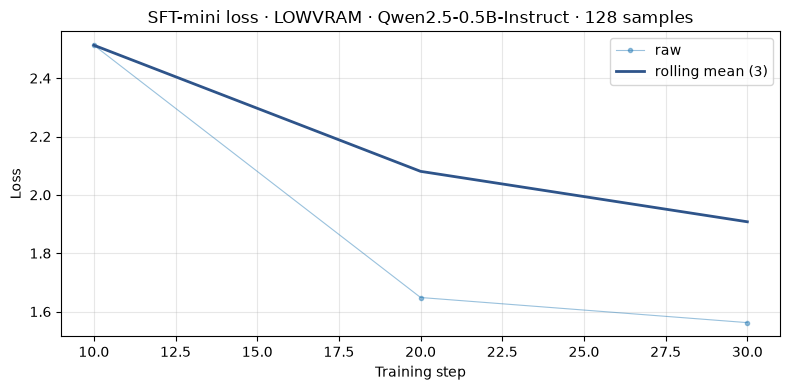

In [9]:
losses = [log["loss"] for log in trainer.state.log_history if "loss" in log]
steps = [log["step"] for log in trainer.state.log_history if "loss" in log]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps, losses, marker="o", markersize=3, linewidth=0.8, alpha=0.45, label="raw")
if len(losses) >= 3:
    import pandas as pd

    smooth = pd.Series(losses).rolling(3, min_periods=1).mean()
    ax.plot(steps, smooth, linewidth=2.0, color="#2e548a", label="rolling mean (3)")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.set_title(f"SFT-mini loss · {COMPUTE_TIER} · {BASE_MODEL.split('/')[-1]} · {SFT_SLICE} samples")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(screenshot_dir / "02-sft-loss.png", dpi=120)
plt.show()

## 4. Save adapter + sanity-check generation

In [10]:
trainer.model.save_pretrained(str(ADAPTER_OUT))
tokenizer.save_pretrained(str(ADAPTER_OUT))
print(f"Saved SFT adapter to {ADAPTER_OUT}")

import json

sft_metrics = {
    "compute_tier": COMPUTE_TIER,
    "base_model": BASE_MODEL,
    "dataset": SFT_DATASET,
    "samples": SFT_SLICE,
    "epochs": NUM_EPOCHS,
    "max_length": MAX_LEN,
    "final_train_loss": float(train_result.training_loss),
    "training_seconds": training_seconds,
    "peak_vram_gib": torch.cuda.max_memory_allocated() / 1024**3,
}
(ADAPTER_OUT / "sft_metrics.json").write_text(
    json.dumps(sft_metrics, indent=2), encoding="utf-8"
)

Saved SFT adapter to C:\Users\Laptop\OneDrive\Laptop\WorkSpace\VinAI\Session\Day22-Track3-DPO-Alignment-Lab\adapters\sft-mini


294

In [11]:
# Sanity: generate 1 sample to confirm the adapter loaded correctly.
if COMPUTE_TIER == "LOWVRAM":
    model.config.use_cache = True
    model.eval()
else:
    FastLanguageModel.for_inference(model)
prompt = "Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào."
messages = [{"role": "user", "content": prompt}]
inputs = tokenizer.apply_chat_template(
    messages, return_tensors="pt", add_generation_prompt=True
).to("cuda")
with torch.no_grad():
    out = model.generate(
        input_ids=inputs,
        max_new_tokens=128 if COMPUTE_TIER == "LOWVRAM" else 200,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
generated = tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True)
print(f"PROMPT: {prompt}\n")
print(f"SFT-mini response:\n{generated}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


PROMPT: Giải thích ngắn gọn (3-4 câu) thuật toán quicksort hoạt động thế nào.

SFT-mini response:
 Quicksort là một thuật toán sắp xếp có thể phân loại các phần tử trong một danh sách hoặc mảng theo thứ tự tăng dần hoặc giảm dần. Nó sử dụng một phương pháp gọi là "tìm kiếm giữa" để chọn phần tử từ đầu đến cuối của danh sách và sau đó phân loại chúng thành hai phần tử khác nhau. Sau khi đã phân loại các phần tử, thuật toán sẽ tìm kiếm giữa các phần tử này và tiếp tục phân loại các phần tử khác nhau cho đến khi tất cả các phần tử được sắp xếp.


## 5. Vibe-coding callout

Bạn vừa tái tạo Lab 21 trong ~10 phút. Một câu hỏi để brainstorm:

> **Thật ra, bạn cần *bao nhiêu* SFT để DPO có ý nghĩa?**
>
> Thử thay `SFT_SLICE = 1000` → `100`. Re-run NB1 → NB3 với SFT yếu hơn.
> Quan sát: reward gap có còn tăng được không? Output coherent không?
>
> Đây là 1 design decision *think-hard zone* (xem VIBE-CODING.md): không có
> đáp án sẵn trong deck. Hypothesize trước, train sau, viết kết quả vào
> `submission/REFLECTION.md` § 6.

**Next:** NB2 — load + format preference data.